In [2]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
# Download and get the path to the dataset folder
path = kagglehub.dataset_download("mubashirsidiki/student-academic-performance-500-students")

# Combine the directory path with the specific filename
import os
file_path = os.path.join(path, "student_performance.csv")

# Load the data using the full path
df = pd.read_csv(file_path)

print("Data successfully loaded!")
print(df.head())

100%|██████████| 6.26k/6.26k [00:00<00:00, 4.72MB/s]

Extracting files...
Data successfully loaded!
  student_id  gender  age  study_hours_per_week  attendance_rate  \
0    STU0001    Male   15                    25             63.8   
1    STU0002  Female   15                     2             54.7   
2    STU0003  Female   19                    10             90.5   
3    STU0004    Male   16                    26             66.8   
4    STU0005  Female   15                    25             73.0   

  parent_education internet_access extracurricular  previous_score  \
0         Bachelor             Yes             Yes              41   
1         Bachelor             Yes             Yes              83   
2      High School             Yes              No              73   
3      High School              No             Yes              75   
4      High School              No             Yes              67   

   final_score passed  
0           67    Yes  
1           28     No  
2           49     No  
3           70    Yes  
4   

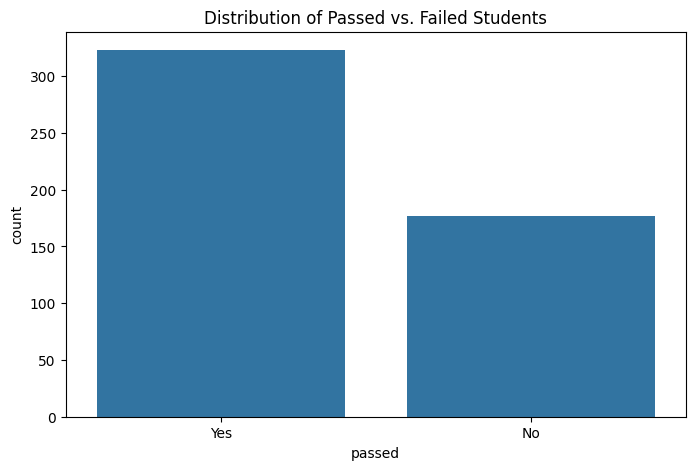

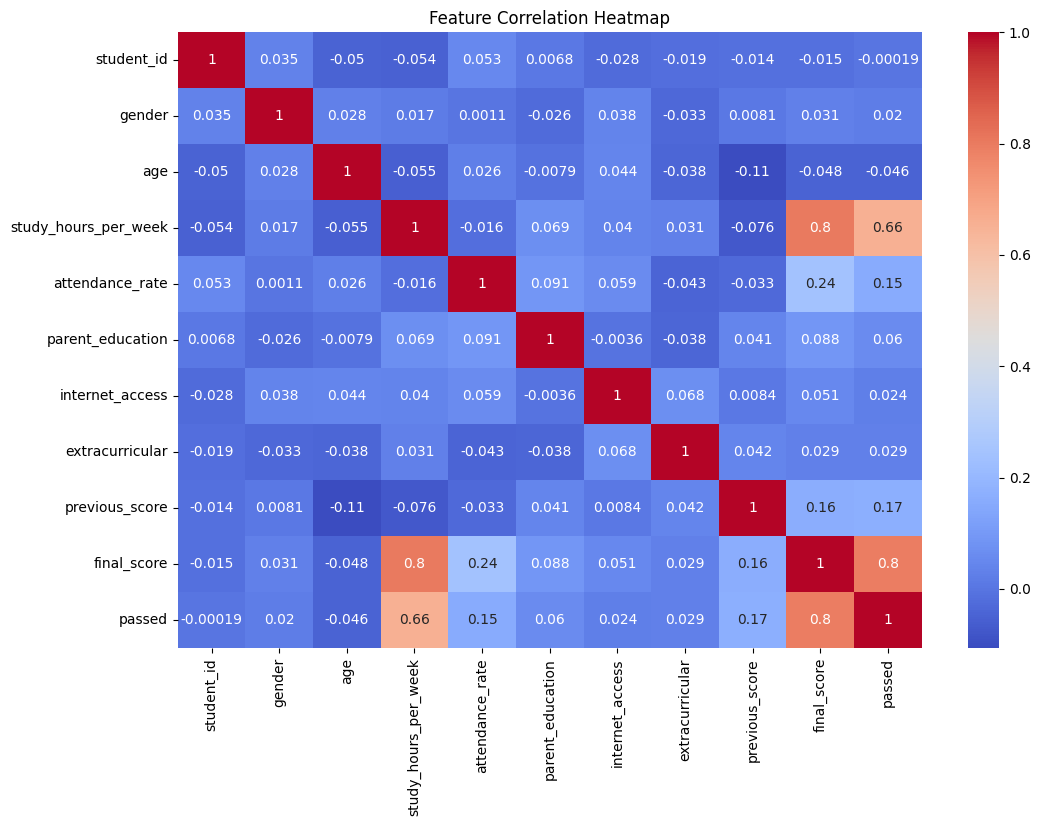

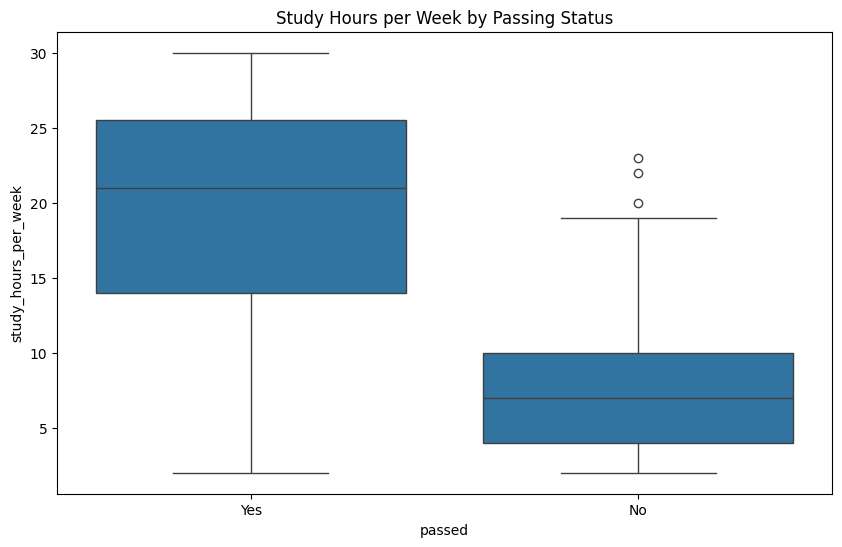

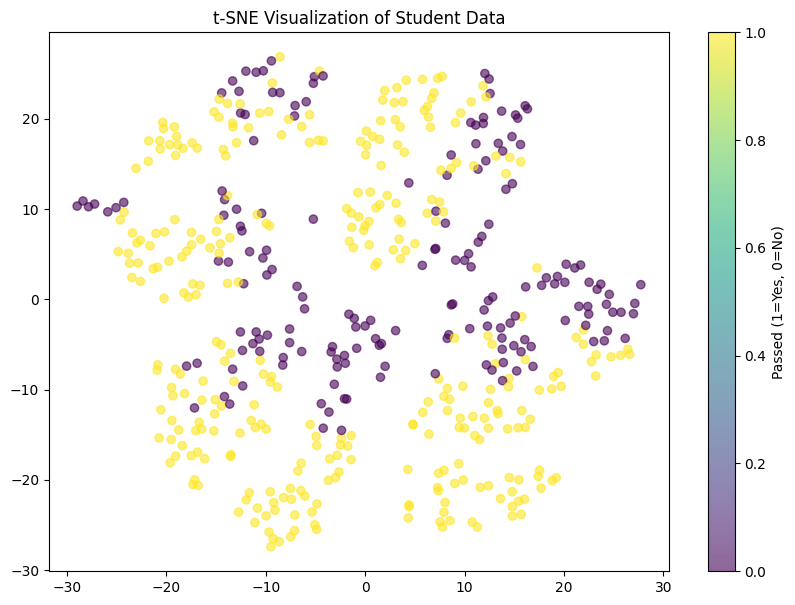

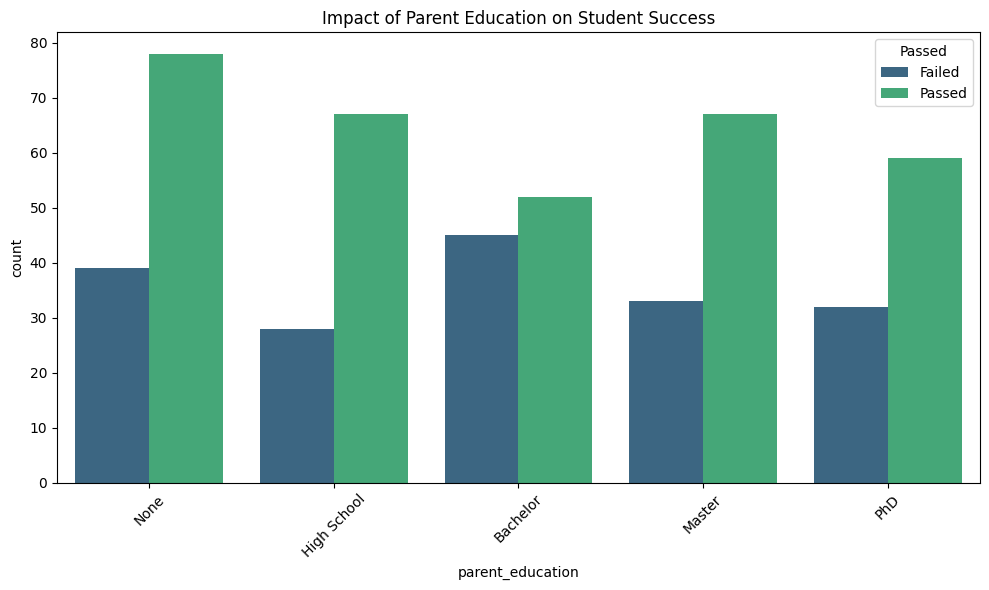

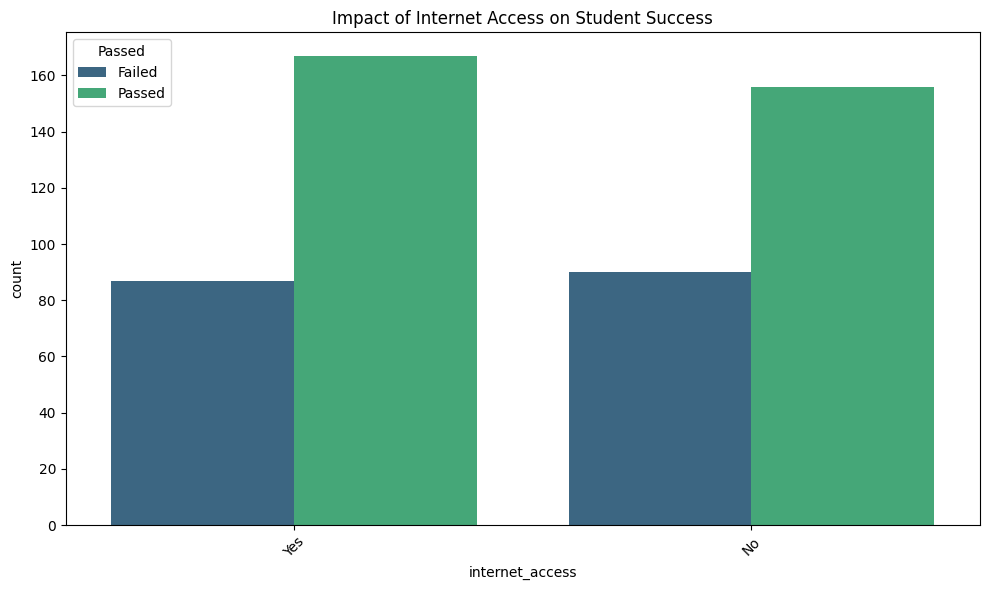

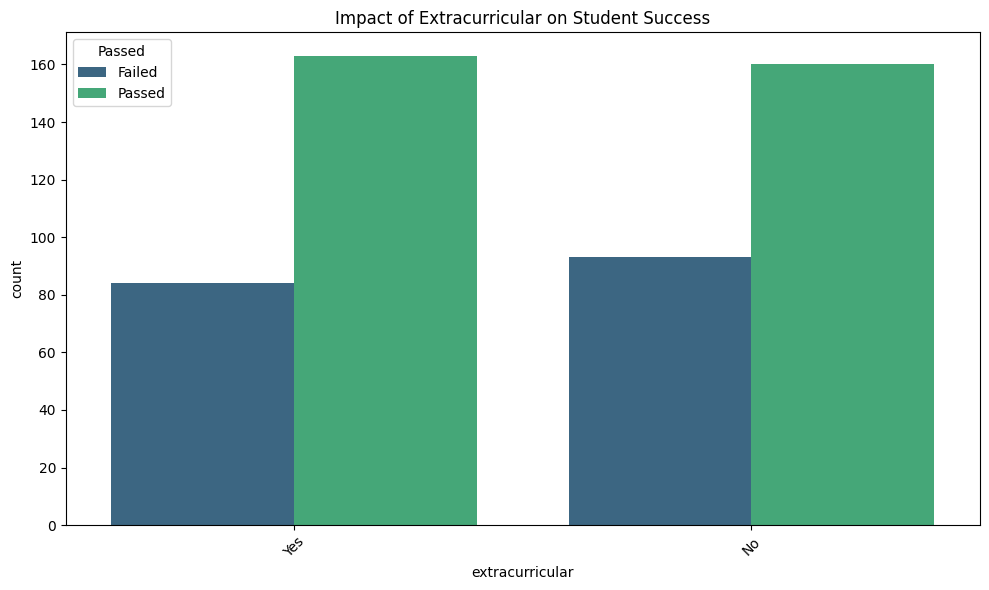

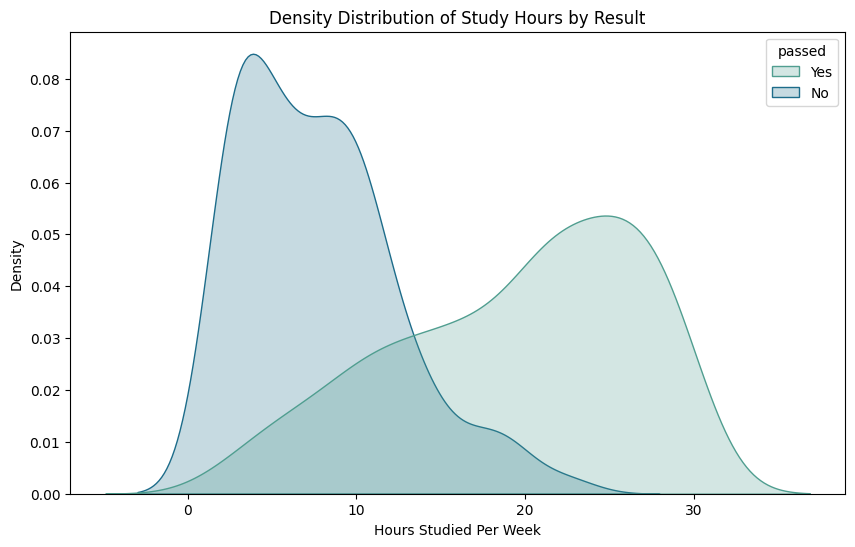

In [12]:
# Load data
df = pd.read_csv(file_path)

# Label Distribution (Checks Class Imbalance)
plt.figure(figsize=(8, 5))
sns.countplot(x='passed', data=df)
plt.title('Distribution of Passed vs. Failed Students')
plt.savefig('label_distribution.png')

# Correlation Heatmap
# Note: Encode categorical variables first to include them in correlation
df_encoded = df.copy()
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = le.fit_transform(df[col])

plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# Feature vs. Target (Example: Study Hours vs. Final Score)
plt.figure(figsize=(10, 6))
sns.boxplot(x='passed', y='study_hours_per_week', data=df)
plt.title('Study Hours per Week by Passing Status')
plt.savefig('study_hours_boxplot.png')

# t-SNE Visualization (High-Dimensional Data to 2D)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded.drop(['student_id', 'passed'], axis=1))
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_encoded['passed'], cmap='viridis', alpha=0.6)
plt.colorbar(label='Passed (1=Yes, 0=No)')
plt.title('t-SNE Visualization of Student Data')
plt.savefig('tsne_plot.png')

# Categorical Analysis (Grouped Bar Charts)
# Explicitly define the order for education to ensure "None" is included and levels are logical

# This converts any actual Nulls to the string "None" and removes hidden spaces
df['parent_education'] = df['parent_education'].fillna('None').astype(str).str.strip()
df['passed'] = df['passed'].astype(str).str.strip()

# Define logic
categorical_features = ['parent_education', 'internet_access', 'extracurricular']
edu_order = ['None', 'High School', 'Bachelor', 'Master', 'PhD']

for feature in categorical_features:
    plt.figure(figsize=(10, 6))

    # Force the current feature to be cleaned strings as well
    df[feature] = df[feature].fillna('Unknown').astype(str).str.strip()

    current_order = edu_order if feature == 'parent_education' else None

    # Plotting - Note: 'hue' must match the case 'Yes' and 'No' in your data
    sns.countplot(x=feature, hue='passed', data=df, palette='viridis', order=current_order, hue_order=['No', 'Yes'])

    plt.title(f'Impact of {feature.replace("_", " ").title()} on Student Success')
    plt.legend(title='Passed', labels=['Failed', 'Passed'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{feature}_vs_passed.png')
    plt.show()

# Numerical Distribution (Alternative to Boxplot)
# This creates an overlapping KDE plot to show the "density" of study hours
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='study_hours_per_week', hue='passed', fill=True, common_norm=False, palette='crest')
plt.title('Density Distribution of Study Hours by Result')
plt.xlabel('Hours Studied Per Week')
plt.savefig('study_hours_density.png')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [10]:
# Prepare Features and Target
X = df_encoded.drop(['student_id', 'final_score', 'passed'], axis=1)
y = df_encoded['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionary of models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000)
}

# Example of Hyperparameter Tuning for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_rf.fit(X_train, y_train)

# Evaluation Loop
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    print(f"--- {name} ---")
    print(classification_report(y_test, predictions))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.92      0.67      0.77        36
           1       0.84      0.97      0.90        64

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.64      0.73        36
           1       0.82      0.94      0.88        64

    accuracy                           0.83       100
   macro avg       0.84      0.79      0.80       100
weighted avg       0.83      0.83      0.82       100

--- Neural Network (MLP) ---
              precision    recall  f1-score   support

           0       1.00      0.61      0.76        36
           1       0.82      1.00      0.90        64

    accuracy                           0.86       100
   macro avg       0.91      0.81      0.83      

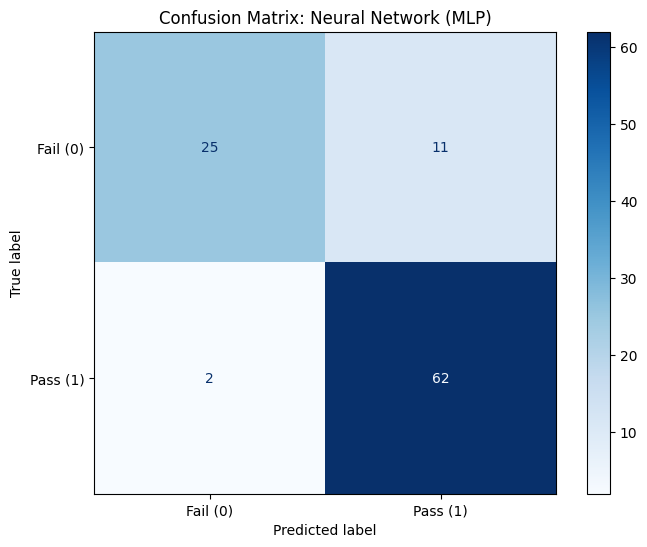

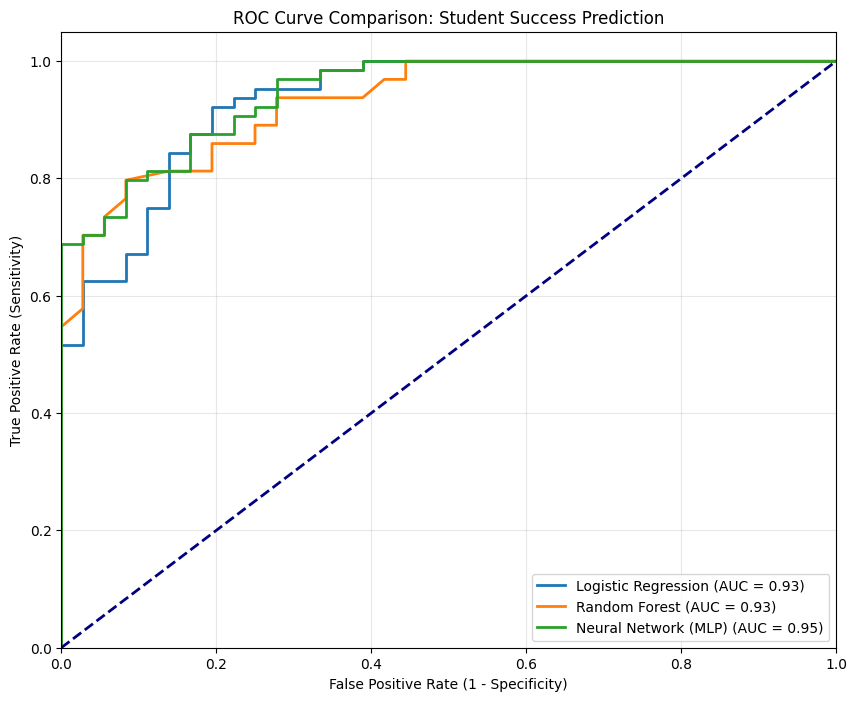

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Re-define X, y, X_test, y_test, and models for self-sufficiency
# Assuming df_encoded is available from previous cells
X = df_encoded.drop(['student_id', 'final_score', 'passed'], axis=1)
y = df_encoded['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionary of models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, random_state=42)
}

# Train models (as they are needed for predictions in this cell)
for name, model in models.items():
    model.fit(X_train, y_train)

# Confusion Matrix for the Neural Network
mlp_model = models["Neural Network (MLP)"]
mlp_preds = mlp_model.predict(X_test)
cm = confusion_matrix(y_test, mlp_preds)

# Plotting the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail (0)', 'Pass (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix: Neural Network (MLP)')
plt.savefig('mlp_confusion_matrix.png')
plt.show()

# ROC/AUC Curve Comparison
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get predicted probabilities for the 'Passed' class (index 1)
    # Using predict_proba ensures we can calculate the AUC
    y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot the 'Random Guess' baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison: Student Success Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('roc_auc_comparison.png')
plt.show()